# Function 3: Minimise medicine side effects
You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine. Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects). 

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from scipy.stats import norm

In [7]:
def load_inputs(file_path):
    with open(file_path, "r") as f:
        content = f.read()

    # Make the file a proper list of lists
    content = "[" + content.replace("]\n[", "],[") + "]"

    # Safe eval with restricted globals
    return eval(content, {"array": np.array})


def load_outputs(file_path):
    with open(file_path, "r") as f:
        content = f.read()

    content = "[" + content.replace("]\n[", "],[") + "]"

    return eval(content, {"np": np})


def get_input_points(function_number, file_path="../inputs.txt"):
    if not 1 <= function_number <= 8:
        raise ValueError("Function number must be between 1 and 8")

    data = load_inputs(file_path)
    index = function_number - 1

    inputs = [dataset[index] for dataset in data]
    return np.array(inputs)


def get_output_points(function_number, file_path="../outputs.txt"):
    if not 1 <= function_number <= 8:
        raise ValueError("Function number must be between 1 and 8")

    data = load_outputs(file_path)
    index = function_number - 1

    outputs = [row[index] for row in data]
    return np.array(outputs)

# Load inputs
X = np.load(r'initial_inputs.npy')
y = np.load(r'initial_outputs.npy')


# Get input and outputs from submissions
inputs_array = get_input_points(3)
outputs_array = get_output_points(3)


# Append inputs_f1_array to X
X = np.vstack((X, inputs_array))

# Append outputs_f1_array to Y
y = np.hstack((y, outputs_array))

print("New shape of X:", X.shape)
print("New shape of Y:", y.shape)


New shape of X: (25, 3)
New shape of Y: (25,)


Using Bayesian Optimisation and considering an Upper Confidence Bound acquisition function. Surrogate Model: A probabilistic model (Gaussian Process) that approximates the objective function.

In [8]:
kernel = ConstantKernel(1.0) * RBF(length_scale=0.05) + WhiteKernel()
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5, normalize_y=True)
gp.fit(X, y)

GaussianProcessRegressor(alpha=1e-05,
                         kernel=1**2 * RBF(length_scale=0.05) + WhiteKernel(noise_level=1),
                         normalize_y=True)

In [9]:
def expected_improvement(model, Y_sample, xi=1e-5):
    best_x = X[np.argmax(y)]
    X_candidates = best_x + 0.03 * np.random.randn(50000, 3)
    X_candidates = np.clip(X_candidates, 0, 1)
    mu, sigma = model.predict(X_candidates, return_std=True)
    best = np.max(Y_sample)

    imp = mu - best - xi
    Z = imp / (sigma + 1e-9)
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)

    return X_candidates[np.argmax(ei)]

next_point = expected_improvement(gp, y)
formatted_next_query = f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}"

print("Next Query Point:", formatted_next_query)

Next Query Point: 0.302209-0.514289-0.517645


To optimize the acquisition function, we will simply use gridsearch over a space of 10,000 grid points

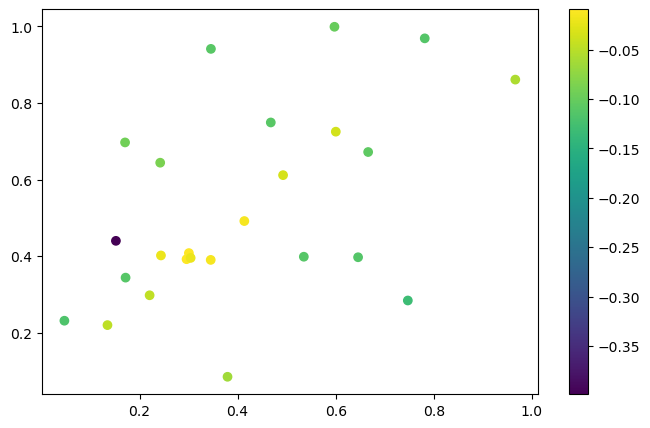

In [10]:
# Define grid of points
# We know the input is in the range 0.000000 to 0.999999
x1 = np.linspace(0.000000, .999999, 100)  # Assuming the search space is within [0, 1] for both dimensions
# We know the input is in the range 0.000000 to 0.999999
x2 = np.linspace(0.000000, .999999, 100)
X_grid = np.array(np.meshgrid(x1, x2)).reshape(2, -1).T

fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)
plt.scatter(X[:, 0], X[:, 1], c = y)
plt.colorbar()